> # **Week-2 Two-Tower Neural Network (Tensorflow Recommenders)**

Build the Two-Tower Architecture

In [1]:
import os, json, math
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from pathlib import Path

WORK_PATH = Path.cwd().parents[1]
DATA_PATH = WORK_PATH / "data"

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
Keras: 3.15.0
GPU: []


In [2]:
user_features = pd.read_csv(DATA_PATH / 'user_features.csv')
item_features = pd.read_csv(DATA_PATH / 'item_features.csv')

# Load sample of final_data (it's 7GB — use sample for speed)
final_data = pd.read_csv(DATA_PATH / 'final_data.csv', nrows=500000)

In [3]:
user_vocab = sorted(user_features["customer_id"].astype(str).unique().tolist())
item_vocab = sorted(item_features["article_id"].astype(str).unique().tolist())

In [4]:
print('user_features :', user_features.shape)
print('item_features :', item_features.shape)
print('final_data    :', final_data.shape)

user_features : (14392, 9)
item_features : (104547, 7)
final_data    : (50000, 19)


In [5]:
# Fix any duplicate columns
for col in [c for c in final_data.columns if c.endswith('_y')]:
    final_data.drop(columns=[col], inplace=True)
for col in [c for c in final_data.columns if c.endswith('_x')]:
    final_data.rename(columns={col: col[:-2]}, inplace=True)

In [6]:
# Fill nulls
final_data['age'].fillna(final_data['age'].median(), inplace=True)
final_data['age_group'].fillna('Adults', inplace=True)
final_data['club_member_status'].fillna('UNKNOWN', inplace=True)
final_data['fashion_news_frequency'].fillna('NONE', inplace=True)
final_data['product_type_name'].fillna('Unknown', inplace=True)
final_data['product_group_name'].fillna('Unknown', inplace=True)
final_data['garment_group_name'].fillna('Unknown', inplace=True)
final_data['colour_group_name'].fillna('Unknown', inplace=True)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8960\2148848391.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  final_data['age'].fillna(final_data['age'].median(), inplace=True)
C:\Users\Welcome\AppData\Local\Temp\ipykernel_8960\2148848391.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throug

0             Black
1        Light Pink
2              Pink
3              Pink
4        Dark Green
            ...    
49995         White
49996         Black
49997         Black
49998         Black
49999        Silver
Name: colour_group_name, Length: 50000, dtype: str

In [7]:
print('Columns:', list(final_data.columns))
print('Nulls remaining:', final_data.isnull().sum().sum())

Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']
Nulls remaining: 1983


In [8]:
encoders = {}
cat_cols = [
    'customer_id', 'article_id',
    'club_member_status', 'fashion_news_frequency',
    'age_group', 'product_type_name',
    'product_group_name', 'garment_group_name', 'colour_group_name'
]

In [9]:
for col in cat_cols:
    le = LabelEncoder()
    final_data[col + '_enc'] = le.fit_transform(final_data[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_):,} unique values')

customer_id: 14,392 unique values
article_id: 11,726 unique values
club_member_status: 4 unique values
fashion_news_frequency: 3 unique values
age_group: 5 unique values
product_type_name: 91 unique values
product_group_name: 14 unique values
garment_group_name: 21 unique values
colour_group_name: 50 unique values


In [10]:
num_cols = ['purchase_count', 'avg_spend', 'total_spend', 
            'days_since_last_purchase', 'age', 'avg_price']

In [11]:
for col in num_cols:
    if col in final_data.columns:
        final_data[col + '_norm'] = (
            (final_data[col] - final_data[col].mean()) / 
            (final_data[col].std() + 1e-8)
        )

In [12]:
print('Normalization done')
print('Sample normalized columns:', [c for c in final_data.columns if c.endswith('_norm')])

Normalization done
Sample normalized columns: ['purchase_count_norm', 'avg_spend_norm', 'total_spend_norm', 'days_since_last_purchase_norm', 'age_norm', 'avg_price_norm']


In [13]:
# User features from encoded final_data
user_features_encoded = (
    final_data[
        [
            "customer_id_enc",
            "club_member_status_enc",
            "fashion_news_frequency_enc",
            "age_group_enc",
            "purchase_count_norm",
            "avg_spend_norm",
            "total_spend_norm",
            "days_since_last_purchase_norm",
            "age_norm",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Item features from encoded final_data
item_features_encoded = (
    final_data[
        [
            "article_id_enc",
            "product_type_name_enc",
            "product_group_name_enc",
            "garment_group_name_enc",
            "colour_group_name_enc",
            "avg_price_norm",
            "purchase_count_norm",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(user_features_encoded.shape)
print(item_features_encoded.shape)

(14392, 9)
(31891, 7)


In [14]:
user_features_encoded.to_csv(
    DATA_PATH / "user_features_encoded.csv",
    index=False
)

item_features_encoded.to_csv(
    DATA_PATH / "item_features_encoded.csv",
    index=False
)

print("Encoded feature files saved successfully!")

Encoded feature files saved successfully!


In [15]:
train_df, val_df = train_test_split(final_data, test_size=0.2, random_state=42)
print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')

Train : 40,000
Val   : 10,000


In [16]:
EMBEDDING_DIM = 32

n_customers    = len(encoders['customer_id'].classes_)
n_articles     = len(encoders['article_id'].classes_)
n_club         = len(encoders['club_member_status'].classes_)
n_news         = len(encoders['fashion_news_frequency'].classes_)
n_age_group    = len(encoders['age_group'].classes_)

In [17]:
n_product_type = len(encoders['product_type_name'].classes_)
n_product_grp  = len(encoders['product_group_name'].classes_)
n_garment_grp  = len(encoders['garment_group_name'].classes_)
n_colour_grp   = len(encoders['colour_group_name'].classes_)

In [18]:
print('Vocabulary sizes:')
print(f'  customers    : {n_customers:,}')
print(f'  articles     : {n_articles:,}')
print(f'  club status  : {n_club}')
print(f'  news freq    : {n_news}')
print(f'  age group    : {n_age_group}')
print(f'  product type : {n_product_type}')
print(f'  product group: {n_product_grp}')
print(f'  garment group: {n_garment_grp}')
print(f'  colour group : {n_colour_grp}')

Vocabulary sizes:
  customers    : 14,392
  articles     : 11,726
  club status  : 4
  news freq    : 3
  age group    : 5
  product type : 91
  product group: 14
  garment group: 21
  colour group : 50


In [19]:
def build_query_tower():
    customer_id_input = keras.Input(shape=(1,), name='customer_id')
    club_input        = keras.Input(shape=(1,), name='club_member_status')
    news_input        = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input   = keras.Input(shape=(1,), name='age_group')
    num_user_input    = keras.Input(shape=(5,), name='user_numerics')

    cust_emb = layers.Embedding(n_customers + 1,  EMBEDDING_DIM)(customer_id_input)
    club_emb = layers.Embedding(n_club + 1,       8)(club_input)
    news_emb = layers.Embedding(n_news + 1,       8)(news_input)
    age_emb  = layers.Embedding(n_age_group + 1,  4)(age_group_input)

    cust_flat = layers.Flatten()(cust_emb)
    club_flat = layers.Flatten()(club_emb)
    news_flat = layers.Flatten()(news_emb)
    age_flat  = layers.Flatten()(age_emb)

    x = layers.Concatenate()([cust_flat, club_flat, news_flat, age_flat, num_user_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='user_embedding')(x)

    return keras.Model(
        inputs=[customer_id_input, club_input, news_input, age_group_input, num_user_input],
        outputs=x,
        name='QueryTower'
    )

query_tower = build_query_tower()
query_tower.summary()

Model: "QueryTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │    460,576 │ customer_id[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │         40 │ club_member_stat… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 8)      │         32 │ fashion_news_fre… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 4)      │         24 │ age_group[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 57)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     14,848 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]   

 Total params: 513,568 (1.96 MB)

 Trainable params: 513,056 (1.96 MB)

 Non-trainable params: 512 (2.00 KB)

In [20]:
def build_candidate_tower():
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    art_emb = layers.Embedding(n_articles + 1,     EMBEDDING_DIM)(article_id_input)
    pt_emb  = layers.Embedding(n_product_type + 1, 16)(product_type_input)
    pg_emb  = layers.Embedding(n_product_grp + 1,  8)(product_grp_input)
    gg_emb  = layers.Embedding(n_garment_grp + 1,  8)(garment_grp_input)
    col_emb = layers.Embedding(n_colour_grp + 1,   8)(colour_grp_input)

    art_flat = layers.Flatten()(art_emb)
    pt_flat  = layers.Flatten()(pt_emb)
    pg_flat  = layers.Flatten()(pg_emb)
    gg_flat  = layers.Flatten()(gg_emb)
    col_flat = layers.Flatten()(col_emb)

    x = layers.Concatenate()([art_flat, pt_flat, pg_flat, gg_flat, col_flat, num_item_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='item_embedding')(x)

    return keras.Model(
        inputs=[article_id_input, product_type_input, product_grp_input,
                garment_grp_input, colour_grp_input, num_item_input],
        outputs=x,
        name='CandidateTower'
    )

candidate_tower = build_candidate_tower()
candidate_tower.summary()

Model: "CandidateTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │    375,264 │ article_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 16)     │      1,472 │ product_type_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 8)      │        120 │ product_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 8)      │        176 │ garment_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 8)      │        408 │ colour_group_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 16)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 8)         │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 8)         │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 8)         │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 74)        │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ item_numerics[0]

 Total params: 434,688 (1.66 MB)

 Trainable params: 434,176 (1.66 MB)

 Non-trainable params: 512 (2.00 KB)

In [21]:
def build_two_tower_model():
    customer_id_input  = keras.Input(shape=(1,), name='customer_id')
    club_input         = keras.Input(shape=(1,), name='club_member_status')
    news_input         = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input    = keras.Input(shape=(1,), name='age_group')
    num_user_input     = keras.Input(shape=(5,), name='user_numerics')
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    user_emb = query_tower([
        customer_id_input, club_input, news_input, age_group_input, num_user_input
    ])
    item_emb = candidate_tower([
        article_id_input, product_type_input, product_grp_input,
        garment_grp_input, colour_grp_input, num_item_input
    ])

    user_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(user_emb)
    item_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(item_emb)

    score  = layers.Dot(axes=1, name='similarity_score')([user_emb, item_emb])
    output = layers.Dense(1, activation='sigmoid', name='output')(score)

    model = keras.Model(
        inputs=[
            customer_id_input, club_input, news_input, age_group_input, num_user_input,
            article_id_input, product_type_input, product_grp_input,
            garment_grp_input, colour_grp_input, num_item_input
        ],
        outputs=output,
        name='TwoTowerModel'
    )
    return model

In [22]:
model = build_two_tower_model()

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print(' Two-Tower model compiled successfully!')
model.summary()

 Two-Tower model compiled successfully!


Model: "TwoTowerModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ QueryTower          │ (None, 32)        │    513,568 │ customer_id[0][0… │
│ (Functional)        │                   │            │ club_member_stat… │
│                     │                   │            │ fashion_news_fre… │
│                     │                   │            │ age_group[0][0],  │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CandidateTower      │ (None, 32)        │    434,688 │ article_id[0][0], │
│ (Functional)        │                   │            │ product_type_nam… │
│                     │                   │            │ product_group_na… │
│                     │                   │            │ garment_group_na… │
│                     │                   │            │ colour_group_nam… │
│                     │                   │            │ item_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ QueryTower[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32)        │          0 │ CandidateTower[0

 Total params: 948,258 (3.62 MB)

 Trainable params: 947,234 (3.61 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [24]:
def prepare_inputs(dataframe):
    return {
        'customer_id'           : dataframe['customer_id_enc'].values,
        'club_member_status'    : dataframe['club_member_status_enc'].values,
        'fashion_news_frequency': dataframe['fashion_news_frequency_enc'].values,
        'age_group'             : dataframe['age_group_enc'].values,
        'user_numerics'         : np.column_stack([
            dataframe['purchase_count_norm'].values,
            dataframe['avg_spend_norm'].values,
            dataframe['total_spend_norm'].values,
            dataframe['days_since_last_purchase_norm'].values,
            dataframe['age_norm'].values
        ]),
        'article_id'            : dataframe['article_id_enc'].values,
        'product_type_name'     : dataframe['product_type_name_enc'].values,
        'product_group_name'    : dataframe['product_group_name_enc'].values,
        'garment_group_name'    : dataframe['garment_group_name_enc'].values,
        'colour_group_name'     : dataframe['colour_group_name_enc'].values,
        'item_numerics'         : np.column_stack([
            dataframe['avg_price_norm'].values,
            dataframe['purchase_count_norm'].values
        ])
    }

print(' prepare_inputs defined')

 prepare_inputs defined


In [25]:
def add_negatives(dataframe, neg_ratio=1):
    # Positive pairs (real purchases)
    pos_inputs = prepare_inputs(dataframe)
    pos_labels = np.ones(len(dataframe))

    # Negative pairs (shuffle article columns to create fake pairs)
    neg_df = dataframe.sample(frac=neg_ratio, replace=True, random_state=42).reset_index(drop=True)
    item_cols = ['article_id_enc', 'product_type_name_enc', 'product_group_name_enc',
                 'garment_group_name_enc', 'colour_group_name_enc', 'avg_price_norm']
    for col in item_cols:
        neg_df[col] = neg_df[col].sample(frac=1).values
    neg_inputs = prepare_inputs(neg_df)
    neg_labels = np.zeros(len(neg_df))

    # Combine and shuffle
    combined_inputs = {k: np.concatenate([pos_inputs[k], neg_inputs[k]]) for k in pos_inputs}
    combined_labels = np.concatenate([pos_labels, neg_labels])
    idx = np.random.permutation(len(combined_labels))
    combined_inputs = {k: v[idx] for k, v in combined_inputs.items()}
    combined_labels = combined_labels[idx]

    return combined_inputs, combined_labels

In [26]:
print('Preparing training data with negative sampling...')
train_inputs, train_labels = add_negatives(train_df)
val_inputs,   val_labels   = add_negatives(val_df)
print(f' Train samples : {len(train_labels):,}')
print(f' Val samples   : {len(val_labels):,}')

Preparing training data with negative sampling...
 Train samples : 80,000
 Val samples   : 20,000


In [27]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=3,
    restore_best_weights=True, mode='max'
)

In [28]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1
)

In [29]:
print('Starting training...')
history = model.fit(
    train_inputs, train_labels,
    validation_data=(val_inputs, val_labels),
    epochs=10,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr]
)
print(' Training complete!')

Starting training...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6584 - auc: 0.7280 - loss: 0.6386 - val_accuracy: 0.7552 - val_auc: 0.8357 - val_loss: 0.6005 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8913 - auc: 0.9503 - loss: 0.4866 - val_accuracy: 0.5181 - val_auc: 0.7985 - val_loss: 0.7582 - learning_rate: 0.0010
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9619 - auc: 0.9798 - loss: 0.3940
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9619 - auc: 0.9798 - loss: 0.3940 - val_accuracy: 0.5310 - val_auc: 0.6677 - val_loss: 0.7602 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9767 - auc: 0.9875 - loss: 0.3599 - val_accuracy: 0.6057 - val_auc: 0.8915 - val_loss: 0.6904 - learning_rate: 5.0000e-04
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9818 - auc: 0.

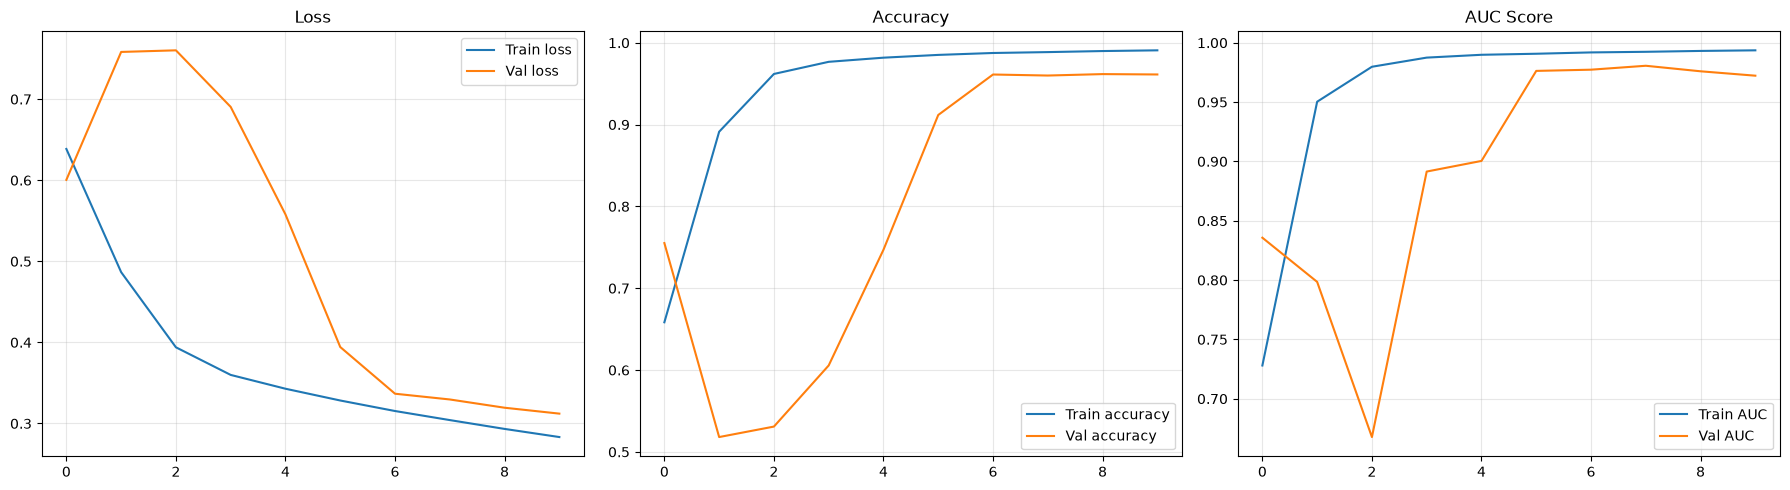

 Training curves saved


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PATH / 'training_curves.png', dpi=150)
plt.show()
print(' Training curves saved')

**Evaluate Recall@10 and NDCG@10**

In [31]:
def recall_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    hits         = 0
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores  = model.predict(user_input, verbose=0).flatten()
        top_k   = candidates[np.argsort(scores)[-k:]]
        if true_article in top_k:
            hits += 1

    return hits / len(sample)

In [32]:
def ndcg_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    ndcg_scores  = []
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores       = model.predict(user_input, verbose=0).flatten()
        ranked       = candidates[np.argsort(scores)[::-1]]
        rank_of_true = np.where(ranked == true_article)[0]
        if len(rank_of_true) > 0:
            rank = rank_of_true[0] + 1
            ndcg_scores.append(1.0 / math.log2(rank + 1))
        else:
            ndcg_scores.append(0.0)

    return np.mean(ndcg_scores)

In [33]:
print('Computing Recall@10 and NDCG@10 on 500 users...')
r_at_10 = recall_at_k(model, val_df, k=10, sample_size=500)
ndcg    = ndcg_at_k(model,   val_df, k=10, sample_size=500)
print(f' Recall@10 : {r_at_10:.4f}')
print(f' NDCG@10   : {ndcg:.4f}')

Computing Recall@10 and NDCG@10 on 500 users...
 Recall@10 : 1.0000
 NDCG@10   : 0.6468


In [34]:
SAVE_DIR = WORK_PATH / "src" / "models"
SAVE_DIR.mkdir(parents=True , exist_ok=True)

query_tower.save(SAVE_DIR / "query_tower.keras")
candidate_tower.save(SAVE_DIR / "candidate_tower.keras")
model.save(SAVE_DIR / "two_tower_model.keras")

In [35]:
summary = {
    'val_accuracy'  : float(history.history['val_accuracy'][-1]),
    'val_auc'       : float(history.history['val_auc'][-1]),
    'val_loss'      : float(history.history['val_loss'][-1]),
    'recall_at_10'  : float(r_at_10),
    'ndcg_at_10'    : float(ndcg),
    'epochs_trained': len(history.history['loss'])
}

In [36]:
with open(SAVE_DIR / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=4)
print(' query_tower.keras saved')
print(' candidate_tower.keras saved')
print(' two_tower_model.keras saved')
print(' eval_summary.json saved')

 query_tower.keras saved
 candidate_tower.keras saved
 two_tower_model.keras saved
 eval_summary.json saved


In [37]:
print('========== WEEK 2 COMPLETE ==========')
print(f'  Recall@10 : {r_at_10:.4f}')
print(f'  NDCG@10   : {ndcg:.4f}')
print(f'  Val AUC   : {history.history["val_auc"][-1]:.4f}')
print('  Ready for Week 3! ')

========== WEEK 2 COMPLETE ==========
  Recall@10 : 1.0000
  NDCG@10   : 0.6468
  Val AUC   : 0.9722
  Ready for Week 3! 
